In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import other_utils

In [3]:
evaluations_dt = pd.read_csv('../models_performances_22032025.csv')
evaluations_dt = evaluations_dt.sort_values(by=['spearman','mse'], ascending = [False, True]).reset_index(drop=True)

In [4]:
evaluations_dt2 = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_22042025/*.csv')
evaluations_dt = evaluations_dt[(evaluations_dt['time'].str.contains('2025-04-1')) ] 

/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, _ = spearmanr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, _ = pearsonr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, _ = spearmanr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, _ = pearsonr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantIn

In [5]:
evaluations_dt2[evaluations_dt2['HLA'] == 'A1101']

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path
41,A1101,Hubber,HLA,0.8,30,0.0001,0.0001,110,0.732367,0.734125,1.166454,0.788916,0.385084,1.080025,2025-04-23 01:46:26,/global/scratch/users/sergiomar10/losses/ESMCB...
77,A1101,Hubber,epitope,0.95,30,0.0001,0.0001,110,0.787887,0.781715,0.750055,0.683913,0.604596,0.866057,2025-04-23 03:01:35,/global/scratch/users/sergiomar10/losses/ESMCB...
106,A1101,Hubber,HLA,0.85,30,0.0001,0.0001,110,0.789466,0.763282,0.817398,0.709153,0.569095,0.904100,2025-04-23 02:10:33,/global/scratch/users/sergiomar10/losses/ESMCB...
208,A1101,Hubber,epitope,0.85,30,0.0001,0.0001,110,0.706796,0.703373,1.116295,0.825610,0.411526,1.056549,2025-04-23 02:56:53,/global/scratch/users/sergiomar10/losses/ESMCB...
219,A1101,Hubber,epitope,0.8,30,0.0001,0.0001,110,0.774275,0.752930,0.832946,0.718779,0.560898,0.912659,2025-04-23 03:04:54,/global/scratch/users/sergiomar10/losses/ESMCB...
278,A1101,Hubber,HLA,0.95,30,0.0001,0.0001,110,0.791990,0.759437,0.845442,0.713024,0.554311,0.919479,2025-04-23 00:10:27,/global/scratch/users/sergiomar10/losses/ESMCB...


In [6]:
evaluations_dt = pd.concat([evaluations_dt, evaluations_dt2], axis=0)
evaluations_dt = evaluations_dt.reset_index(drop=True)

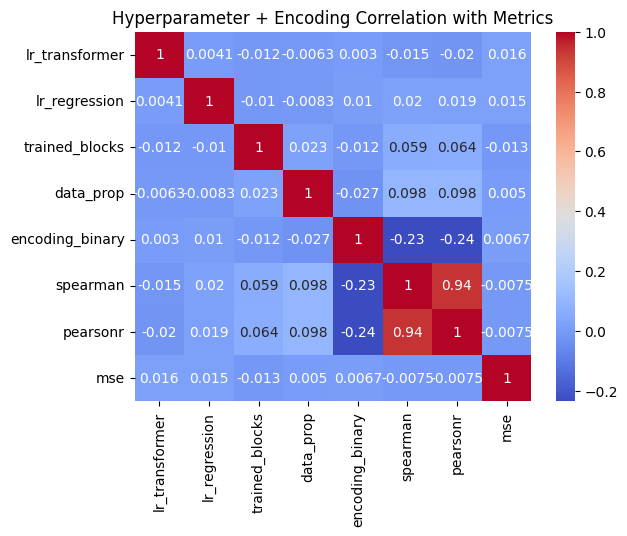

Encoding vs Spearman correlation: nan (p = nan)


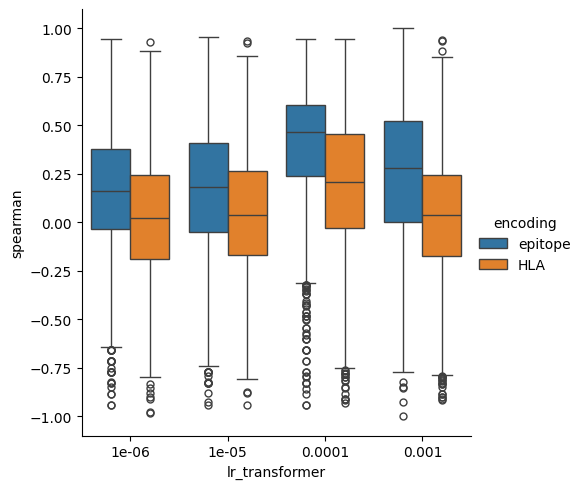

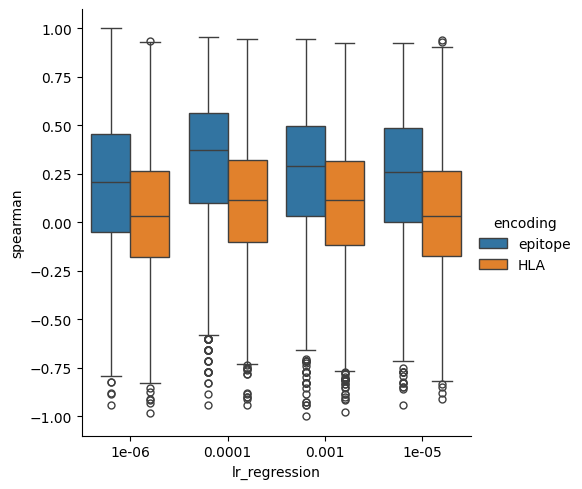

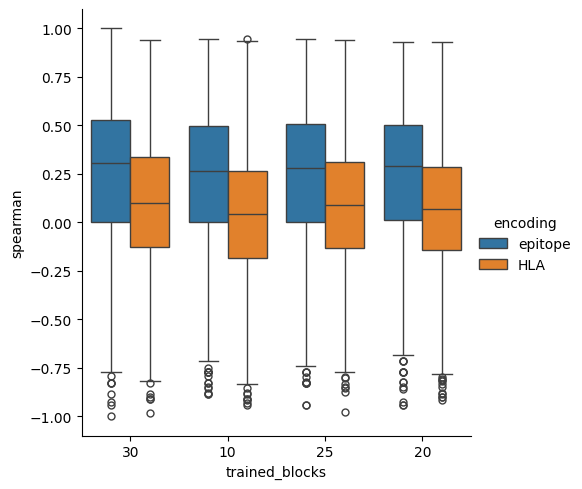

In [7]:
# Copy the DataFrame
df_corr = evaluations_dt.copy()

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['Losses_binary'] = df_corr['Losses'].map({'MSE': 0, 'Hubber': 1})

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['encoding_binary'] = df_corr['encoding'].map({'epitope': 0, 'HLA': 1})

# Select numeric columns
numeric_hyperparams = df_corr[[
    'lr_transformer', 'lr_regression', 'trained_blocks', 'data_prop', 'encoding_binary',  'spearman', 'pearsonr', 'mse'
]].astype(float)

# Compute correlation matrix
correlation_matrix = numeric_hyperparams.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Hyperparameter + Encoding Correlation with Metrics")
plt.show()


from scipy.stats import pointbiserialr
# Point-biserial correlation
r, p = pointbiserialr(df_corr['encoding_binary'], df_corr['spearman'])
print(f"Encoding vs Spearman correlation: {r:.3f} (p = {p:.3g})")

evaluations_dt['lr_transformer'] = evaluations_dt['lr_transformer'].astype(float)

# sns.catplot(data=evaluations_dt, x='lr_transformer', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='lr_transformer', y='spearman', hue='encoding', kind='box')

# sns.catplot(data=evaluations_dt, x='lr_regression', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='lr_regression', y='spearman', hue='encoding', kind='box')

# sns.catplot(data=evaluations_dt, x='trained_blocks', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='trained_blocks', y='spearman', hue='encoding', kind='box')

In [8]:
evaluations_dt[(evaluations_dt['HLA'] == ('A1101'))]['encoding'].unique()

array(['HLA', 'epitope'], dtype=object)

In [9]:
evaluations_dt_sorted =  evaluations_dt.sort_values(by='mse', ascending = True)
evaluations_dt_sorted['Model'] = evaluations_dt_sorted['HLA'] + ' ' + evaluations_dt_sorted['encoding']
evaluations_dt_sorted = evaluations_dt_sorted.drop_duplicates('Model')
# evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

In [10]:
evaluations_dt_sorted[(evaluations_dt_sorted['HLA'] == ('A1101'))]

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model
187,A1101,Hubber,HLA,0.5,30,0.0001,0.0001,110,0.797718,0.783970,0.736651,0.654020,0.611662,0.858284,2025-04-18 06:36:05,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
12854,A1101,Hubber,epitope,0.95,30,0.0001,0.0001,110,0.787887,0.781715,0.750055,0.683913,0.604596,0.866057,2025-04-23 03:01:35,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 epitope


In [11]:
results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:
    # Load training data for the current allele
    formatted_HLA = allele.split(' ')[0]# .replace('*', '').replace(':', '').
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

All test datasets were empty for HLA B4402 epitope. Skipping this allele.


In [12]:
pd.merge(left=metrics_df, right=evaluations_dt_sorted[['HLA','time','Model']], on='Model', how='left').reset_index(drop=True).sort_values(by=['HLA_x','Model'], ascending=True).head(30)

,HLA_x,spearman,pearsonr,mse,test_size,path,training_data,encoding,Model,HLA_y,time
52,A0101,0.59,0.62,2.4,126,/global/scratch/users/sergiomar10/losses/ESMCB...,3790,HLA,A0101 HLA,A0101,2025-04-22 23:56:12
47,A0101,0.54,0.57,1.9,128,/global/scratch/users/sergiomar10/losses/ESMCB...,3790,epitope,A0101 epitope,A0101,2025-04-19 15:28:37
46,A0201,0.52,0.51,1.8,472,/global/scratch/users/sergiomar10/losses/ESMCB...,16550,HLA,A0201 HLA,A0201,2025-04-23 00:33:55
44,A0201,0.57,0.56,1.6,495,/global/scratch/users/sergiomar10/losses/ESMCB...,16550,epitope,A0201 epitope,A0201,2025-04-19 13:43:10
30,A0211,0.72,0.66,0.79,17,/global/scratch/users/sergiomar10/losses/ESMCB...,715,epitope,A0211 epitope,A0211,2025-04-19 15:51:21
18,A0216,-0.24,-0.28,0.47,8,/global/scratch/users/sergiomar10/losses/ESMCB...,604,HLA,A0216 HLA,A0216,2025-04-18 10:32:25
40,A0301,0.58,0.56,1.5,223,/global/scratch/users/sergiomar10/losses/ESMCB...,6278,HLA,A0301 HLA,A0301,2025-04-17 19:29:03
49,A0301,0.56,0.53,2.1,220,/global/scratch/users/sergiomar10/losses/ESMCB...,6278,epitope,A0301 epitope,A0301,2025-04-23 02:41:18
25,A1101,0.8,0.78,0.74,110,/global/scratch/users/sergiomar10/losses/ESMCB...,5717,HLA,A1101 HLA,A1101,2025-04-18 06:36:05
29,A1101,0.78,0.77,0.77,107,/global/scratch/users/sergiomar10/losses/ESMCB...,5717,epitope,A1101 epitope,A1101,2025-04-23 03:01:35


In [13]:
hla_sequences = []

# Process each HLA and its evaluation file
for hla, eval_path in evaluations_dt_sorted[['HLA', 'path']].values:

    # # Load evaluation data
    dt = pd.read_csv(eval_path)
    sequences = dt['sequence'].unique()
    hla_formatted = f"HLA-{hla}"  # e.g., 'HLA-A1101'

    # Collect HLA and sequence pairs
    for seq in sequences:
        hla_sequences.append([hla_formatted, seq])


In [14]:
# Load Data S2: Monoallelic benchmark dataset with predictions
test_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S2.csv')

In [15]:
test_data['hla'] = test_data['hla'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [16]:
evaluations_dt_sorted = evaluations_dt[evaluations_dt['encoding'] == 'epitope'].sort_values(by='mse', ascending = True) #.drop_duplicates('HLA') #[evaluations_dt['Losses'] == 'MSE']
evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'].apply(len) == 8] 
# evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

In [17]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/IEDB_full_subset_filtered_out_MHCFlurry.csv', sep = ',', header = 0)
IEDB_full.head()

,Assay - Qualitative Measurement,peptide,MHC Restriction - Name
0,Positive-High,LITGRLQSL,HLA-A2
1,Positive,LIYDSSLCDL,HLA-A2
2,Positive,GLLGTLVQ,HLA-A2
3,Positive,NLTISDVSV,HLA-A2
4,Positive,LPAVVGLSPGEQEY,HLA-B*35:01


In [18]:
IEDB_full['HLA'] = IEDB_full['MHC Restriction - Name'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

### Creating jobs for evalution

In [1]:
import pandas as pd

evaluations_dt_sorted = pd.read_csv('../../performances/models_performances_23042025.csv')
# evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == 'A0201']
rfd_peptides = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/rdfiffusion_output_peptides.csv')
# rfd_peptides = rfd_peptides[(rfd_peptides['length'] < 12) & (rfd_peptides['hla_allele'] == 'HLA-A*0201')]
print(len(rfd_peptides))
rfd_peptides.head(2)

rfd_peptides['HLA'] = [x.replace('HLA-','').replace('*','') for x in rfd_peptides['hla_allele'].astype('str')] 
rfd_peptides['title'].str.replace('HLA-','').str.extract(r'([A-Z]\d{2}\d{2})')[0].unique()


174220


array([nan, 'B2705', 'B5801', 'A2402', 'S1060'], dtype=object)

In [2]:
hlas_in_rfd = rfd_peptides['hla_allele'].unique()
hlas_in_rfd

array(['B5301', 'B2705', 'B1502', nan, 'N0101', 'B5703', 'B8', 'A0201',
       'B1801', 'B3501', 'A2402', 'B4403', 'B3508', 'B1301', 'A2',
       'B4405', 'B5801', 'B3505', 'B1501', 'A6', 'A0206', 'A0207',
       'B4001', 'B5803', 'B5701', 'C1203', 'C1202', 'B2706', 'B3503'],
      dtype=object)

In [4]:
# rfd_peptides.drop_duplicates().groupby('hla_allele').size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(20)

In [3]:
peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')
peptides_eval_set_ESMCBA = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['Model'] == 'A0201 epitope']
peptides_eval_set_ESMCBA.head()

,sequence,prediction,measured,Model,HLA,allele_x,allele_y,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile,mhc_log,Peptide,netmhc_log,length,allele
668,RAKLLGAEEK,4.583677,4.698979,A0201 epitope,A0201,A0201,HLAA0201,RAKLLGAEEK,27739.021138,28.874250,0.044665,0.004254,62.744674,4.443091,RAKLLGAEEK,1.795666,10,NaN
669,GRAKLLGAEEK,4.581459,4.698979,A0201 epitope,A0201,A0201,HLAA0201,GRAKLLGAEEK,26034.732016,22.627125,0.151088,0.006578,37.359049,4.415553,GRAKLLGAEEK,1.901453,11,NaN
670,FGLAKLLGA,3.497342,2.032256,A0201 epitope,A0201,A0201,HLAA0201,FGLAKLLGA,1191.320556,1.868375,0.350082,0.211256,1.767120,3.076029,FGLAKLLGA,0.789468,9,NaN
671,GLAKLLGAEEK,4.270145,4.698979,A0201 epitope,A0201,A0201,HLAA0201,GLAKLLGAEEK,16518.976351,8.905000,0.151236,0.010201,22.192310,4.217983,GLAKLLGAEEK,1.648501,11,NaN
672,LAKLLGAEEK,4.839673,4.698979,A0201 epitope,A0201,A0201,HLAA0201,LAKLLGAEEK,26911.222605,25.389875,0.017940,0.003987,99.286603,4.429933,LAKLLGAEEK,1.773866,10,NaN


In [18]:
import random

AA = list("ACDEFGHIKLMNPQRSTVWY")
N_MUTANTS = 10

# Anchor positions (0-indexed) for nonamers and decamers
ANCHORS = {
    9: (1, 8),   # P2 and PΩ for 9-mers
   10: (1, 9)    # P2 and PΩ for 10-mers
}

def mutate_non_anchors(seq, rng):
    L = len(seq)
    anchors = ANCHORS.get(L)
    if not anchors:
        # sequence length not supported → return original
        return seq
    s = list(seq)
    for i in range(L):
        if i in anchors:
            continue
        s[i] = rng.choice(AA)
    return "".join(s)

def generate_mutants(seqs, seed=0):
    rng = random.Random(seed)
    mutants = []
    for seq in seqs:
        L = len(seq)
        if L not in ANCHORS:
            # skip sequences of unsupported lengths
            continue
        for _ in range(N_MUTANTS):
            mutants.append(mutate_non_anchors(seq, rng))
    return mutants

In [5]:
# from transformers import AutoTokenizer, EsmForMaskedLM
# import torch
# import numpy as np

# # Check if GPU is available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# # Load the tokenizer and model
# tok = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
# model = EsmForMaskedLM.from_pretrained("facebook/esm2_t33_650M_UR50D").to(device).eval()

# # Define standard amino acids (exclude special and ambiguous tokens)
# standard_amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
# amino_acid_ids = [tok.convert_tokens_to_ids(aa) for aa in standard_amino_acids]

# def generate_9mers_with_esm2(n_samples=10, temperature=1.0):
#     samples = []
#     with torch.no_grad():
#         for _ in range(n_samples):
#             # Initialize sequence: [CLS] <mask> <mask> ... <mask> (9 masks)
#             seq = [tok.cls_token_id] + [tok.mask_token_id] * 9
#             seq_tensor = torch.tensor([seq]).to(device)  # Ensure tensor is on the same device as model

#             # Iteratively predict each masked position
#             for pos in range(1, 10):  # Positions 1 to 9
#                 # Get logits for the current sequence
#                 outputs = model(seq_tensor).logits  # Shape: [1, seq_len, vocab_size]
#                 logits = outputs[0, pos, :] / temperature  # Logits for the masked position

#                 # Restrict to standard amino acids
#                 logits = logits[amino_acid_ids]
#                 probs = torch.softmax(logits, dim=-1)
#                 next_id = amino_acid_ids[torch.multinomial(probs, 1).item()]

#                 # Update the sequence with the predicted token
#                 seq_tensor[0, pos] = next_id

#             # Decode the sequence (skip [CLS])
#             seq_str = tok.decode(seq_tensor[0, 1:], skip_special_tokens=True)
#             samples.append(seq_str)

#     return samples

In [7]:
# # Example usage
# samples = generate_9mers_with_esm2(n_samples=500, temperature=1.0)
# for i, sample in enumerate(samples):
#     print(f"Sample {i+1}: {sample}")

In [19]:
# import pandas as pd

# #join all sequences 'P P N P K K D D E' to 'PPNPKKDD'and make them in a dataframe
# samples_df = pd.DataFrame(samples, columns=['sequence'])
# samples_df['sequence'] = samples_df['sequence'].str.replace(' ', '')
# samples_df.to_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/9mers_esm2.csv', index=False)

samples_df = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/9mers_esm2.csv')

In [34]:
import os
import re
import numpy as np 

name = 'FINAL_RS_RFD_MAC_'
# Set up directories
sh_file_dir       = '/global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH'
output_dir        = '/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK'
mhcflurry_out_dir = os.path.join(output_dir, 'mhcflurry')
logs_dir          = '/global/scratch/users/sergiomar10/logs/RFD_BENCHMARK'

for d in (sh_file_dir, output_dir, mhcflurry_out_dir, logs_dir):
    os.makedirs(d, exist_ok=True)

peptides_eval_set_ESMCBA = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_of_models.csv')

for allele in evaluations_dt_sorted['HLA'].unique():

    if allele != 'A0201':  
        continue

    peptides_eval_set_ESMCBA_subset = peptides_eval_set_ESMCBA[peptides_eval_set_ESMCBA['HLA'] == allele]
    rfd_peptides_subset = rfd_peptides[rfd_peptides['HLA'] == allele]

    #add the RFD peptides to the evaluation set
    peptides = pd.concat([peptides_eval_set_ESMCBA_subset['sequence'], rfd_peptides_subset['epitope']])
    
    #add the mutated peptides
    mutant_df = generate_mutants(peptides_eval_set_ESMCBA_subset["sequence"])

    mutant_dt = pd.DataFrame(mutant_df, columns=['sequence'])
    mutant_dt['HLA'] = allele
    mutant_dt = mutant_dt.head(500)
    #save mutant_df
    mutant_dt.to_csv(f'/global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH/mutant_peptides/mutant_df_{allele}.csv', index=False)

    peptides = np.concatenate([peptides, mutant_df[:500]])


    #add randomly sampled ESM2 peptides
    peptides = np.concatenate([peptides, samples_df['sequence'].values])

    print(f'{allele} - {len(peptides)} peptides')

    for hla in evaluations_dt_sorted['Model'].unique():
        rows = evaluations_dt_sorted[
            evaluations_dt_sorted['HLA'] == allele
        ][['HLA','path']].values

        for allele, eval_path in rows:
            # clean names
            allele_clean = allele.split()[0].replace('*','').replace(':','').replace(' ','')
            hla_clean    = allele_clean.replace('HLA','')

            if hla_clean not in hla:
                print(f"⚠️ HLA mismatch: {hla_clean} not in {hla}")
                continue

            model_fn     = os.path.basename(eval_path).replace('evaluation_','').replace('.csv','_final.pth')
            model_path   = f'/global/scratch/users/sergiomar10/models/ESMCBA_21032025/{hla_clean}/{model_fn}'

            if not os.path.exists(model_path):
                print(f"❌ Model missing: {model_path}")
                continue
            print(f"✅ Using model: {model_path}")

            cleaned = [
                pep for pep in peptides
                if 8 <= len(pep) <= 11 and not re.search(r'[<\(\)\*\s\+]', pep)
            ]
            if not cleaned:
                print(f"⚠️ No peptides for {allele}")
                continue

            # write .pep FASTA
            pepe       = allele_clean.replace('HLA','HLA-')
            fasta_file = os.path.join(output_dir, f"{pepe}.pep")
            with open(fasta_file,'w') as f:
                for i, pep in enumerate(cleaned,1):
                    f.write(f">pep{i}\n{pep}\n")

            hla = hla.replace(' ','_')
            encoding = hla.split('_')[1]

            # build commands
            esmcba_cmd = (
                f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian \n"
                f"python3 /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/embeddings_generation.py "
                f"--model_path {model_path} "
                f"--name {hla}-{allele} "
                f"--hla {allele} "
                f"--encoding {encoding} "
                f"--output_dir {output_dir} "
                f"--peptides {' '.join(cleaned)}"
            )
            mhcflurry_cmd = (
                f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools \n"
                f"mhcflurry-predict --alleles {allele_clean} "
                f"--peptides {' '.join(cleaned)} "
                f"--out {os.path.join(output_dir, allele_clean+name+'_mhc_flurry.csv')}"
            )
            netmhc_cmd = (
                f"cd {output_dir} && "
                f"/global/scratch/users/sergiomar10/tools/netMHCpan-4.1/netMHCpan "
                f"-a HLA-{allele_clean} -f {pepe}.pep -BA -xls -xlsfile {name}_{allele_clean}_netmhc.xls"
            )
            

            # package them up
            for tag, cmd in (('esmcba', esmcba_cmd),
                            ('mhcflurry', mhcflurry_cmd),
                            ('netmhcpan', netmhc_cmd)):

                if tag == 'esmcba':
                    run_id = f"{hla}_{tag}"
                    sh_path= os.path.join(sh_file_dir, f"{name}_{run_id}.sh")
                else:
                    run_id = f"{hla}_{tag}"
                    sh_path= os.path.join(sh_file_dir, f"{name}_{run_id}.sh")
                with open(sh_path,'w') as sb:
                    sb.write("#!/bin/bash\n")
                    sb.write("#SBATCH --account=co_nilah\n")
                    sb.write("#SBATCH --partition=savio3_gpu\n")
                    sb.write("#SBATCH --cpus-per-task=4\n")
                    sb.write('#SBATCH --qos=savio_lowprio\n')
                    sb.write("#SBATCH --gres=gpu:1\n")
                    sb.write("#SBATCH --time=00:40:00\n")
                    sb.write(f"#SBATCH --job-name={run_id}\n")
                    sb.write(f"#SBATCH --output={logs_dir}/{run_id}_%j.out\n")
                    sb.write(f"#SBATCH --error={logs_dir}/{run_id}_%j.err\n\n")
                    sb.write("source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n")
                    # sb.write("")
                    sb.write(cmd + "\n")

                os.chmod(sh_path, 0o755)
                print(f"✅ Wrote {tag} script: {sh_path}")

            break

A0201 - 19254 peptides
⚠️ HLA mismatch: A0201 not in A3101 epitope
⚠️ HLA mismatch: A0201 not in A3101 epitope
⚠️ HLA mismatch: A0201 not in A1101 HLA
⚠️ HLA mismatch: A0201 not in A1101 HLA
⚠️ HLA mismatch: A0201 not in A1101 epitope
⚠️ HLA mismatch: A0201 not in A1101 epitope
⚠️ HLA mismatch: A0201 not in A3101 HLA
⚠️ HLA mismatch: A0201 not in A3101 HLA
⚠️ HLA mismatch: A0201 not in B5101 epitope
⚠️ HLA mismatch: A0201 not in B5101 epitope
⚠️ HLA mismatch: A0201 not in A3301 HLA
⚠️ HLA mismatch: A0201 not in A3301 HLA
⚠️ HLA mismatch: A0201 not in B1801 HLA
⚠️ HLA mismatch: A0201 not in B1801 HLA
⚠️ HLA mismatch: A0201 not in B1501 epitope
⚠️ HLA mismatch: A0201 not in B1501 epitope
⚠️ HLA mismatch: A0201 not in A6801 HLA
⚠️ HLA mismatch: A0201 not in A6801 HLA
⚠️ HLA mismatch: A0201 not in B1501 HLA
⚠️ HLA mismatch: A0201 not in B1501 HLA
⚠️ HLA mismatch: A0201 not in A6801 epitope
⚠️ HLA mismatch: A0201 not in A6801 epitope
⚠️ HLA mismatch: A0201 not in A0101 HLA
⚠️ HLA mismatch: 

No sequences found for length 8


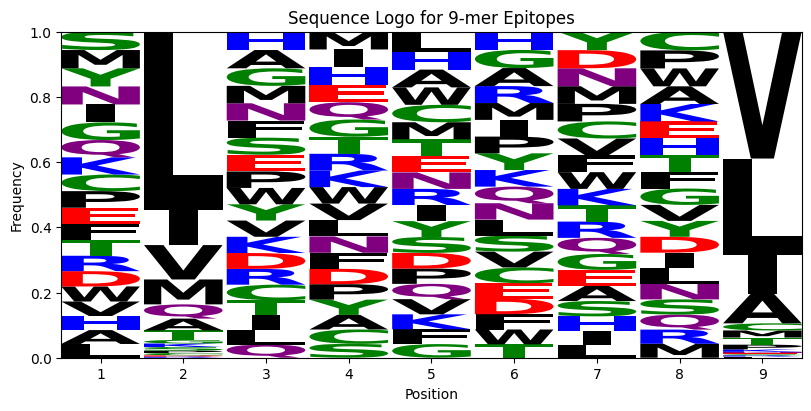

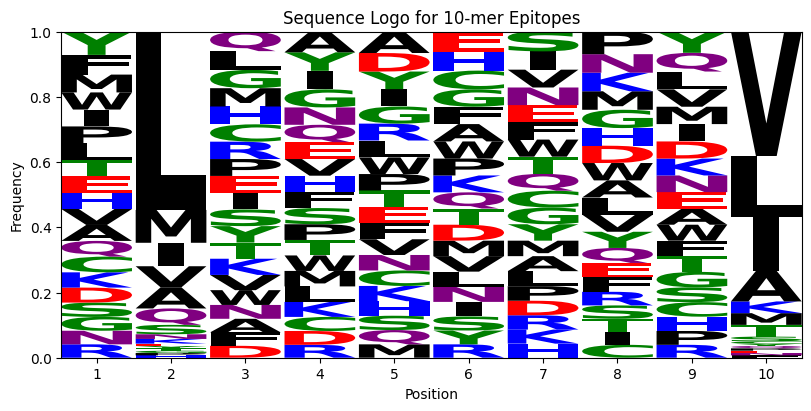

No sequences found for length 11
No sequences found for length 12
No sequences found for length 13
No sequences found for length 14


In [35]:
import matplotlib.pyplot as plt
import logomaker
import os

# Define standard amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Output directory for saving figures
output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
os.makedirs(output_dir, exist_ok=True)

# Loop through epitope lengths
for n in range(8, 15):
    # Filter sequences from ESCMBA_predictions
    sequences = [x for x in mutant_df if len(x) == n] #.tolist()
        # print(sequences)
    # Only proceed if sequences are found
    if sequences:
        # Initialize frequency matrix
        freq_matrix = np.zeros((n, len(amino_acids)))

        # Compute frequency for each position and amino acid
        for seq in sequences:
            if len(seq) == n:  # Ensure sequence length matches
                for j, aa in enumerate(seq):
                    if aa in amino_acids:
                        freq_matrix[j, amino_acids.index(aa)] += 1
        # break
        # Normalize by number of sequences
        if len(sequences) > 0:
            freq_matrix /= len([seq for seq in sequences if len(seq) == n])

        # Create DataFrame for logomaker
        freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

        # Create figure and axis
        fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

        # Generate sequence logo
        logomaker.Logo(freq_df, ax=ax, color_scheme='chemistry')
        ax.set_xlabel("Position")
        ax.set_ylabel("Frequency")
        ax.set_xticks(range(n))
        ax.set_xticklabels(range(1, n + 1))
        ax.set_title(f"Sequence Logo for {n}-mer Epitopes")

        # Save figure
        output_path = os.path.join(output_dir, f'seqlogo_{n}_random_peptides_mer.pdf')
        plt.savefig(output_path, bbox_inches='tight')
        plt.show()
    else:
        print(f"No sequences found for length {n}")

    # Close figure to free memory
    plt.close(fig)

In [ ]:
len(cleaned)

10982

In [ ]:

    # Save to .pep FASTA file
    pepe = allele_clean.replace('HLA', 'HLA-')
    fasta_filename = os.path.join(output_dir, f"{pepe}.pep")
    with open(fasta_filename, "w") as fout:
        for i, pep in enumerate(cleaned_peptides, 1):
            fout.write(f">pep{i}\n{pep}\n")

    print(f"📁 Saved {len(cleaned_peptides)} peptides for {allele} to {fasta_filename}")

    # Build mhcflurry and netMHCpan commands
    mhcflurry_outfile = os.path.join(mhcflurry_out_dir, f"{allele_clean}_mhc_flurry.csv")
    mhcflurry_cmd = (
        f"mhcflurry-predict --alleles {allele_clean} "
        f"--peptides {' '.join(cleaned_peptides)} "
        f"--out {mhcflurry_outfile}"
    )

    netmhc_cmd = (
        f"cd {output_dir} && "
        f"/global/scratch/users/sergiomar10/ESMCBA/tools/netMHCpan-4.1/netMHCpan "
        f"-a {allele_clean} -f {allele_clean}.pep -BA -xls -xlsfile {allele_clean}_netmhc.xls"
    )

NameError: name 'cleaned_peptides' is not defined

In [ ]:
eval_model_df = pd.DataFrame(evaluated_models_log)

In [ ]:
eval_model_df['model_path'] = eval_model_df['model_path'].str.replace('/global/scratch/users/sergiomar10/models/','')

In [ ]:
import shutil

destination_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA'
os.makedirs(destination_dir, exist_ok=True)

for row in evaluated_models_log:
    src = row['model_path']
    filename = os.path.basename(src)
    dest = os.path.join(destination_dir, filename)

    try:
        shutil.copy2(src, dest)  # copy2 preserves metadata
        print(f"✅ Copied {filename} to {destination_dir}")
    except Exception as e:
        print(f"❌ Failed to copy {src} → {dest}: {e}")


✅ Copied ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.0001_1e-06_AUG_1_HLAA0206_2_0.001_1e-06__1_A0206_Hubber_A0206_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_25_0.001_0.001_AUG_6_HLAA0203_2_0.001_0.001__2_A0203_Hubber_A0203_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.001_1e-06_AUG_3_HLAB3701_1_0.0001_1e-05__1_B3701_0404_Hubber_B3701_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_20_ESMMASK_epitope_FT_20_0.001_1e-06_AUG_1_HLAA2501_1_0.0001_1e-06__1_A2501_0404_Hubber_A2501_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_20_0.001_0.001_AUG_1_HLAA3301_5_0.001_1e-06__4_A3301_Hubber_A3301_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_25_0.001_1e-05_AUG_6_HLAA6802_2_0.001_1e-06__4_A

In [ ]:
# Load Data S3: Training data for MHCflurry 2.0 BA predictor
training_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S3.csv')
print(f"Training data shape: {training_data.shape}")

Training data shape: (713069, 12)


In [ ]:
training_data['allele'] = training_data['allele'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [ ]:
testing_set_filtered = pd.DataFrame()

for HLA in test_datasets_df['HLA'].unique():
    training_data_subset = training_data[training_data['allele'] == HLA]

    test_datasets_df_subset = test_datasets_df[test_datasets_df['HLA'] == HLA]
    test_datasets_df_subset = test_datasets_df_subset[~test_datasets_df_subset['sequence'].isin(training_data_subset['peptide'])]

    testing_set_filtered = pd.concat([testing_set_filtered, test_datasets_df_subset], ignore_index=True)

In [ ]:
import os
import pandas as pd

# Load your test data
# testing_set_filtered = pd.read_csv("path/to/testing_set_filtered.csv")

# Output dirs
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/MHCF_ESMCBA'
output_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4'
mhcflurry_out_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry'
os.makedirs(sh_file_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mhcflurry_out_dir, exist_ok=True)

aa = set("ACDEFGHIKLMNPQRSTVWY")  # valid amino acids

# Loop through each HLA in testing set
unique_hlas = testing_set_filtered['HLA'].unique()
print(f"📊 Found {len(unique_hlas)} unique HLAs in testing set.")

for allele in unique_hlas:
    allele_peptides = testing_set_filtered[testing_set_filtered['HLA'] == allele]['sequence'].unique()
    allele_clean = allele.replace('HLA-', '').replace('*', '').replace(':', '').replace(' ', '')

    # Clean peptides
    cleaned_peptides = [
        ''.join([aa_ for aa_ in p if aa_.upper() in aa])
        for p in allele_peptides if isinstance(p, str)
    ]
    cleaned_peptides = [p for p in cleaned_peptides if p]

    if len(cleaned_peptides) == 0:
        print(f"⚠️ No valid peptides found for {allele}. Skipping.")
        continue

    run_id = f"EVAL_MHCFLURRY_TEST_{allele_clean}"

    # Save to .pep FASTA file
    pepe = allele_clean.replace('HLA', 'HLA-')
    fasta_filename = os.path.join(output_dir, f"{pepe}.pep")
    with open(fasta_filename, "w") as fout:
        for i, pep in enumerate(cleaned_peptides, 1):
            fout.write(f">pep{i}\n{pep}\n")

    print(f"📁 Saved {len(cleaned_peptides)} peptides for {allele} to {fasta_filename}")

    # Build mhcflurry and netMHCpan commands
    mhcflurry_outfile = os.path.join(mhcflurry_out_dir, f"{allele_clean}_mhc_flurry.csv")
    mhcflurry_cmd = (
        f"mhcflurry-predict --alleles {allele_clean} "
        f"--peptides {' '.join(cleaned_peptides)} "
        f"--out {mhcflurry_outfile}"
    )

    netmhc_cmd = (
        f"cd {output_dir} && "
        f"/global/scratch/users/sergiomar10/ESMCBA/tools/netMHCpan-4.1/netMHCpan "
        f"-a {allele_clean} -f {allele_clean}.pep -BA -xls -xlsfile {allele_clean}_netmhc.xls"
    )

    # Write SLURM script
    sh_filepath = os.path.join(sh_file_dir, f"{run_id}.sh")
    try:
        with open(sh_filepath, 'w') as sh_file:
            sh_file.write('#!/bin/bash\n')
            sh_file.write('#SBATCH --account=co_nilah\n')
            sh_file.write('#SBATCH --partition=savio2_1080ti\n')
            sh_file.write('#SBATCH --qos=savio_lowprio\n')
            sh_file.write('#SBATCH --cpus-per-task=4\n')
            sh_file.write('#SBATCH --gres=gpu:1\n')
            sh_file.write('#SBATCH --time=00:40:00\n')
            sh_file.write(f'#SBATCH --job-name={run_id}\n')
            sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.out\n')
            sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.err\n\n')
            sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
            sh_file.write('conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools\n\n')
            sh_file.write(f"{mhcflurry_cmd}\n")
            sh_file.write(f"{netmhc_cmd}\n")

        os.chmod(sh_filepath, 0o755)
        print(f"✅ Created SLURM script: {sh_filepath}")
    except Exception as e:
        print(f"❌ Error writing script for {allele}: {e}")


NameError: name 'testing_set_filtered' is not defined

In [ ]:
allele_clean.replace('HLA', 'HLA-')

'HLA-A2402'